# Notebook 2 - Resampling: bootstrap and cross-validation

Project 1, parts c and d.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from Errors import mse, bias_variance
from OLS import ols_svd
from Resample import bootstrap_bias_variance, kfold_cv, sklearn_cv
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge as SKRidge
np.set_printoptions(precision=4, suppress=True)

## Part c: bias-variance with the bootstrap

The analytical derivation of the bias-variance decomposition, Eq. (2.52), goes in the theory section of the report. Here we study it numerically. For each polynomial degree we bootstrap the training set, fit OLS on every resample, and split the test error into squared bias and variance. The measured bias contains the noise variance, so error equals bias plus variance holds per point.

n=100: lowest bootstrap test error at degree 6 = 0.03658


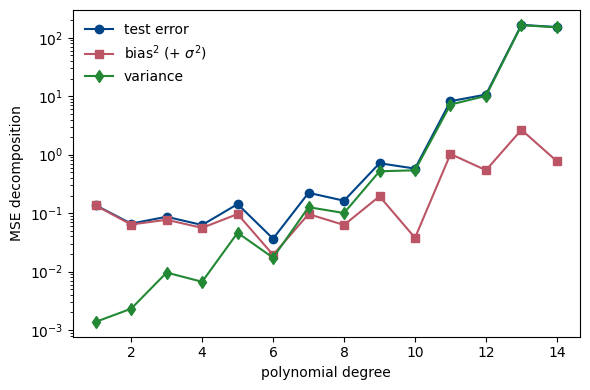

In [2]:
def bv_sweep(n, degrees, n_boot=100, noise=0.1, seed=SEED):
    x, y = make_data(n=n, noise=noise, seed=seed)
    err, bias, var = [], [], []
    for d in degrees:
        X = polynomial_features(x, d)
        Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=seed)
        Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
        fp = lambda Xa, ya, Xb: Xb @ ols_svd(Xa, ya)
        e, b, v = bootstrap_bias_variance(Xtr, Xte, ytr, yte, fp, n_bootstraps=n_boot)
        err.append(e); bias.append(b); var.append(v)
    return np.array(err), np.array(bias), np.array(var)

degrees = list(range(1, 15))
err, bias, var = bv_sweep(100, degrees)
best = degrees[int(np.argmin(err))]
print('n=100: lowest bootstrap test error at degree', best, '=', round(err.min(), 5))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(degrees, err, 'o-', color=BLUE, label='test error')
ax.plot(degrees, bias, 's-', color=RED, label=r'bias$^2$ (+ $\sigma^2$)')
ax.plot(degrees, var, 'd-', color=GREEN, label='variance')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('MSE decomposition')
ax.legend(frameon=False)
fig.tight_layout()
savefig('c_bias_variance', fig)
plt.show()

The test error is a U in the degree. At low degree the bias dominates: the model is too stiff to follow Runge's peak. At high degree the variance dominates: the model chases the noise and swings between resamples. The minimum is where the two balance.

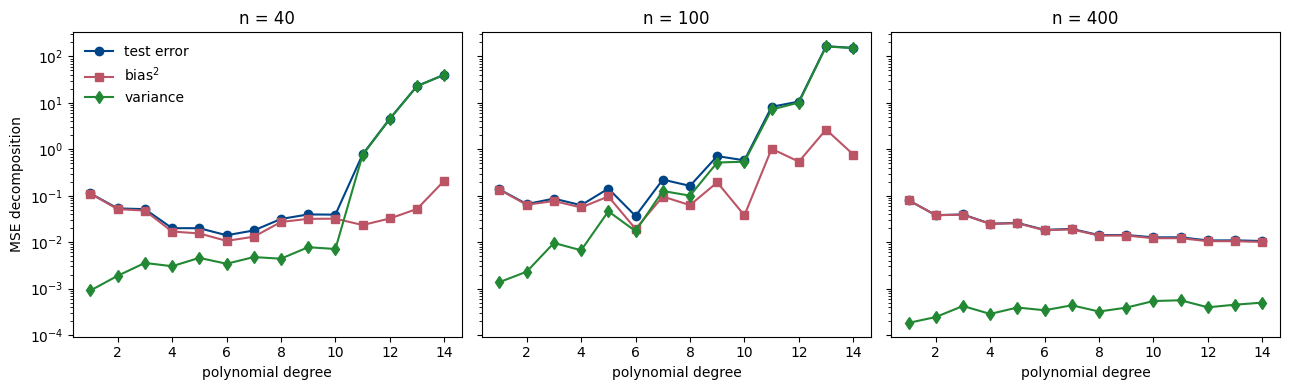

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, n in zip(axes, (40, 100, 400)):
    e, b, v = bv_sweep(n, degrees)
    ax.plot(degrees, e, 'o-', color=BLUE, label='test error')
    ax.plot(degrees, b, 's-', color=RED, label=r'bias$^2$')
    ax.plot(degrees, v, 'd-', color=GREEN, label='variance')
    ax.set_yscale('log')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('polynomial degree')
axes[0].set_ylabel('MSE decomposition')
axes[0].legend(frameon=False)
fig.tight_layout()
savefig('c_bias_variance_n', fig)
plt.show()

More data lowers the variance and pushes the overfitting to higher degree. The bias curve barely moves: a low-degree polynomial is too stiff no matter how much data there is. Data reduces variance, not bias.

## Part d: cross-validation

Cross-validation selects a model without spending a separate test set. We use our own k-fold and scikit-learn KFold with cross_val_score, and check that they agree. Any scaling is fitted inside each fold, on the training folds only, so the held-out fold stays unseen.

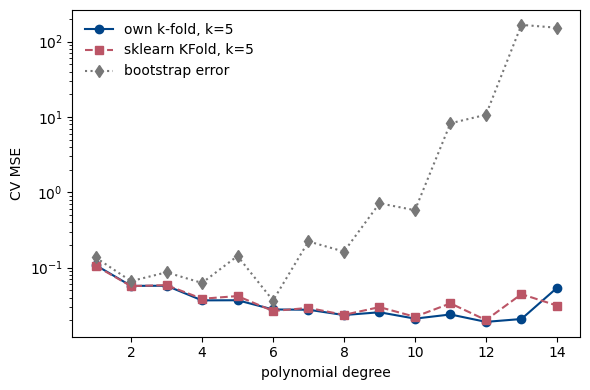

In [4]:
x, y = make_data(n=100, noise=0.1, seed=SEED)
xr = x.reshape(-1, 1)

cv_own, cv_sk = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                          StandardScaler(), LinearRegression())
    cv_own.append(kfold_cv(xr, y, model, k=5)[0])
    cv_sk.append(sklearn_cv(xr, y, model, k=5)[0])

boot_err, _, _ = bv_sweep(100, degrees)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(degrees, cv_own, 'o-', color=BLUE, label='own k-fold, k=5')
ax.plot(degrees, cv_sk, 's--', color=RED, label='sklearn KFold, k=5')
ax.plot(degrees, boot_err, 'd:', color=GREY, label='bootstrap error')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('CV MSE')
ax.legend(frameon=False)
fig.tight_layout()
savefig('d_cv_vs_bootstrap', fig)
plt.show()

The own k-fold and the scikit-learn KFold agree closely. Both track the bootstrap error and point to the same degree window. The bootstrap tends to sit a little higher, since each resample trains on fewer distinct points.

k=5: best alpha 0.000346, CV MSE 0.01985


k=10: best alpha 0.000522, CV MSE 0.01894


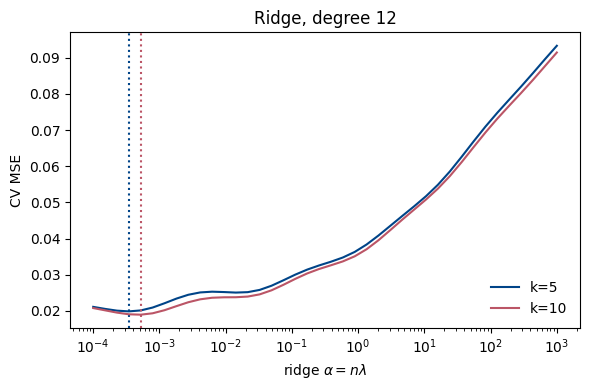

In [5]:
# Ridge: cross-validated MSE over lambda at a fixed high degree, k = 5 and 10
d = 12
alphas = np.logspace(-4, 3, 40)
fig, ax = plt.subplots(figsize=(6, 4))
for k, col in zip((5, 10), (BLUE, RED)):
    cv = []
    for a in alphas:
        model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                              StandardScaler(), SKRidge(alpha=a))
        cv.append(kfold_cv(xr, y, model, k=k)[0])
    cv = np.array(cv)
    best = int(np.argmin(cv))
    print(f'k={k}: best alpha {alphas[best]:.3g}, CV MSE {cv[best]:.5f}')
    ax.plot(alphas, cv, '-', color=col, label=f'k={k}')
    ax.axvline(alphas[best], ls=':', color=col)
ax.set_xscale('log')
ax.set_xlabel(r'ridge $\alpha = n\lambda$')
ax.set_ylabel('CV MSE')
ax.set_title(f'Ridge, degree {d}')
ax.legend(frameon=False)
fig.tight_layout()
savefig('d_ridge_cv_lambda', fig)
plt.show()

The selected penalty is stable between k = 5 and k = 10; the CV MSE changes only in the third decimal. Leave-one-out, k = n, would give a slightly lower-bias estimate at a much higher cost, n fits per alpha instead of k. For this data k = 5 or 10 is the sensible tradeoff.

## Summary of parts c and d

The bootstrap splits the test error into bias and variance and shows the tradeoff directly. Cross-validation gives a cleaner single number for model selection and agrees with the bootstrap on the best degree. Both confirm the part a and b picture, now without relying on one noisy test split. The scaling is fitted inside each fold to avoid leaking the held-out data into the fit.